In [13]:
import sys
import os

# 1. Agregamos la carpeta superior al sistema (para encontrar config.py)
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# 2. Ahora sí importamos tu configuración
try:
    from config import PATHS
    print("✅ Configuración importada correctamente.")
except ImportError:
    print("❌ No se encontró el archivo 'config.py' en la carpeta superior.")
    # Definimos PATHS dummy para que no rompa si falla el import
    PATHS = {"raw_sla": "."} 

# 3. Resto de librerías
import glob
import re
import datetime
import pandas as pd
import numpy as np

✅ Configuración importada correctamente.


In [14]:

def obtener_rango_fechas(nombre_archivo):
    """
    Extrae fechas usando TU patrón validado: 'd-m-y al d-m-y'
    Retorna: Fecha Inicio, Fecha Fin, Etiqueta (Ej: 'ENE 2026 Q1')
    """
    # 1. Limpieza básica
    nombre_limpio = os.path.basename(nombre_archivo).lower()
    
    # 2. TU REGEX (La que sí funcionaba)
    # Busca algo como: "1-12-2025 al 15-12-2025"
    patron = r"(\d{1,2}-\d{1,2}-\d{4})\s+al\s+(\d{1,2}-\d{1,2}-\d{4})"
    
    match = re.search(patron, nombre_limpio)
    
    if not match:
        return None, None, None

    try:
        str_inicio, str_fin = match.groups()
        
        # 3. Conversión directa (Asumiendo formato dd-mm-yyyy del nombre de archivo)
        f_inicio = datetime.datetime.strptime(str_inicio, "%d-%m-%Y")
        f_fin = datetime.datetime.strptime(str_fin, "%d-%m-%Y")

        # 4. Lógica de Quincena (Q1 vs Q2)
        # Regla: Si la fecha fin es el día 15 (o antes), es la primera quincena.
        #        Si la fecha fin es mayor al 15 (ej. 30 o 31), es la segunda quincena.
        quincena_str = "Q1" if f_fin.day <= 15 else "Q2"
        
        # 5. Nombre del Mes (En Español)
        # Usamos f_fin.month para saber a qué mes pertenece el cierre
        meses = ["", "ENE", "FEB", "MAR", "ABR", "MAY", "JUN", 
                 "JUL", "AGO", "SEP", "OCT", "NOV", "DIC"]
        
        # Construimos la etiqueta: "DIC 2025 Q1"
        nombre_etiqueta = f"{meses[f_fin.month]} {f_fin.year} {quincena_str}"
        
        return f_inicio, f_fin, nombre_etiqueta

    except Exception as e:
        print(f"[red]❌ Error calculando fechas en {nombre_archivo}: {e}[/]")
        return None, None, None

In [91]:
import os
import glob
import re
import datetime
import pandas as pd
import numpy as np

# ==========================================
# 1. FUNCIONES UTILITARIAS
# ==========================================
def obtener_rango_fechas(nombre_archivo):
    try:
        nombre_limpio = os.path.basename(nombre_archivo).lower()
        patron = r"(\d{1,2}-\d{1,2}-\d{4})\s+al\s+(\d{1,2}-\d{1,2}-\d{4})"
        match = re.search(patron, nombre_limpio)
        if not match: return None, None, None

        str_inicio, str_fin = match.groups()
        f_inicio = datetime.datetime.strptime(str_inicio, "%d-%m-%Y")
        f_fin = datetime.datetime.strptime(str_fin, "%d-%m-%Y")

        quincena_str = "Q1" if f_fin.day <= 15 else "Q2"
        meses = ["", "ENE", "FEB", "MAR", "ABR", "MAY", "JUN", 
                 "JUL", "AGO", "SEP", "OCT", "NOV", "DIC"]
        nombre_etiqueta = f"{meses[f_fin.month]} {f_fin.year} {quincena_str}"
        return f_inicio, f_fin, nombre_etiqueta
    except Exception:
        return None, None, None

def limpiar_fechas_mixtas(series):
    """
    Función maestra para columnas que vienen sucias (mezcla de fechas, números y texto).
    """
    # 1. Si ya es fecha (datetime), no tocamos nada
    if pd.api.types.is_datetime64_any_dtype(series):
        return series

    # 2. Convertir a numérico (para seriales Excel)
    # Los seriales válidos están entre 35000 (año 1995) y 60000 (año 2064)
    series_nums = pd.to_numeric(series, errors='coerce')
    mask_es_serial = (series_nums > 35000) & (series_nums < 60000)
    
    # Convertimos los seriales seguros
    fechas_excel = pd.to_datetime(series_nums[mask_es_serial], unit='D', origin='1899-12-30')
    
    # 3. El resto lo tratamos como texto con dayfirst=True
    # Solo procesamos lo que NO era serial
    resto = series[~mask_es_serial].astype(str).str.strip()
    # errors='coerce' pondrá NaT a la basura (teléfonos, textos raros)
    fechas_texto = pd.to_datetime(resto, dayfirst=True, errors='coerce')
    
    # 4. Combinar: Preferencia a los seriales, relleno con texto
    return fechas_excel.combine_first(fechas_texto)

# ==========================================
# 2. CONFIGURACIÓN
# ==========================================

# Asegúrate de que PATHS esté definido
# PATHS = {"raw_sla": "C:/Ruta/..."}

NOC_USERS = [
    "GFARFAN", "JVELASQUEZ", "JOLUGO", "KUSEA", "SLOPEZ",
    "EDESPINOZA", "SANDYJIM", "JOCASTILLO", "JESUSGARCIA",
    "DFUENTES", "JOCANTO", "IXMONTILLA", "OMTRUJILLO",
    "LLZERPA", "LUIJIMENEZ"
]

EXCLUIR_SOLUCIONES = [
    "CAMBIO DE CLAVE", "CLIENTE SOLICITO REEMBOLSO", 
    "LLAMADAS DE AGENDAMIENTO", "ORDEN REPETIDA"
]

COLS_EXTRACCION = [
    "FechaInicio", "FechaFin", "FechaInicioQuincena", "Quincena Evaluada",
    "N° Contrato", "Estatus contrato", "N° Orden", "Estatus_orden",
    "Fecha Creacion", "Fecha Impresion", "Fecha Finalizacion", 
    "Grupo Afinidad", "Detalle Orden", "Franquicia",
    "Grupo Trabajo", "Usuario Emisión", "Usuario Impresión", 
    "Usuario Final", "Solucion Aplicada"
]

ORDEN_FINAL = [
    "Fecha Creacion", "Fecha Impresion", "Fecha Finalizacion",
    "SLA Resolucion", "SLA Despacho", "SLA Impresion",
    "Clasificacion", "N° Orden", "N° Contrato", 
    "Grupo Trabajo", "Usuario Final", "Solucion Aplicada",
    "Estatus_orden", "Detalle Orden", "Grupo Afinidad", 
    "Franquicia", "Usuario Emisión", "Usuario Impresión", "Estatus contrato",
    "Quincena Evaluada", "FechaInicio", "FechaFin"
]

ruta_origen = PATHS.get("raw_sla")
if not ruta_origen or not os.path.exists(ruta_origen):
    print(f"❌ Error: Ruta inválida {ruta_origen}")
else:
    archivos = glob.glob(os.path.join(ruta_origen, "*.xlsx"))
    print(f"📂 Se encontraron {len(archivos)} archivos.")

    dataframes_procesados = []

    # ==========================================
    # 3. PROCESAMIENTO
    # ==========================================

    for archivo in archivos:
        nombre_archivo = os.path.basename(archivo)

        if nombre_archivo.startswith("~$") or "Consolidado" in nombre_archivo:
            continue
        
        fecha_inicio, fecha_fin, quincena_nombre = obtener_rango_fechas(nombre_archivo)
        if not fecha_inicio:
            print(f"⚠️ Saltando {nombre_archivo} (Sin fechas válidas)")
            continue

        try:
            # --- C. LECTURA (CAMBIO IMPORTANTE: Sin dtype=str) ---
            # Al quitar dtype=str, dejamos que 'calamine' detecte las fechas nativas de Excel.
            # Esto evita la ambigüedad 1-11 (Enero vs Noviembre).
            df = pd.read_excel(archivo, engine="calamine")
            
            if df.empty: continue

            # --- D. CORRECCIÓN DE FECHAS INTELIGENTE ---
            cols_fecha = ["Fecha Creacion", "Fecha Emisión", "Fecha Final", 
                          "Fecha Impresion", "Fecha Cierre", "Fecha Finalizacion"]
            
            for col in cols_fecha:
                if col in df.columns:
                    # Usamos la función que respeta lo que ya es fecha y arregla lo demás
                    df[col] = limpiar_fechas_mixtas(df[col])

            # --- E. FILTRO CRUZADO ---
            if "Fecha Finalizacion" not in df.columns:
                print(f"❌ {nombre_archivo} falta Fecha Finalizacion")
                continue

            # Filtramos solo por fecha finalización
            df_filtrado = df.query("@fecha_inicio <= `Fecha Finalizacion` <= @fecha_fin").copy()
            
            if len(df_filtrado) == 0:
                print(f"⚠️ {nombre_archivo}: 0 filas. (Rango: {fecha_inicio.date()} al {fecha_fin.date()})")
                continue

            # --- F. ENRIQUECIMIENTO ---
            df_filtrado = df_filtrado.assign(
                FechaInicio = fecha_inicio,
                FechaFin = fecha_fin,
                FechaInicioQuincena = fecha_inicio,
                Quincena_Evaluada = quincena_nombre
            ).rename(columns={"Quincena_Evaluada": "Quincena Evaluada"})

            # --- G. LIMPIEZA NEGOCIO ---
            df_filtrado = df_filtrado.assign(
                Solucion_Norm = lambda x: x["Solucion Aplicada"].fillna("").astype(str).str.upper(),
                Grupo_Norm    = lambda x: x["Grupo Trabajo"].fillna("").astype(str).str.upper(),
                Detalle_Norm  = lambda x: x["Detalle Orden"].fillna("").astype(str).str.upper(),
                Estatus_Norm  = lambda x: x["Estatus_orden"].fillna("").astype(str).str.upper()
            )
            
            mask_excluir = (
                df_filtrado["Solucion_Norm"].isin(EXCLUIR_SOLUCIONES) |
                df_filtrado["Grupo_Norm"].str.contains("GT API FIBEX", na=False) |
                (df_filtrado["Detalle_Norm"] == "PRUEBA DE INTERNET") |
                df_filtrado["Estatus_Norm"].str.contains("CREACIÓN", na=False)
            )
            
            df_final = df_filtrado[~mask_excluir].reindex(columns=COLS_EXTRACCION)
            dataframes_procesados.append(df_final)
            print(f" ✅ {nombre_archivo} -> {len(df_final)} filas OK")

        except Exception as e:
            print(f" ❌ Error crítico en {nombre_archivo}: {e}")

    # ==========================================
    # 4. CONSOLIDACIÓN
    # ==========================================

    print(f"\nConsolidando {len(dataframes_procesados)} DataFrames...")

    if dataframes_procesados:
        review_r = (
            pd.concat(dataframes_procesados, ignore_index=True)
            .assign(
                Grupo_Norm   = lambda x: x['Grupo Trabajo'].fillna('').astype(str).str.upper(),
                Usuario_Norm = lambda x: x['Usuario Final'].fillna('').astype(str).str.upper()
            )
            .assign(
                Clasificacion = lambda x: np.select(
                    condlist=[
                        x['Usuario_Norm'].isin(NOC_USERS),
                        x['Grupo_Norm'].isin(NOC_USERS),
                        x['Usuario_Norm'].str.contains('NOC', na=False),
                        x['Grupo_Norm'].str.contains('OPERACIONES', na=False)
                    ],
                    choicelist=['NOC', 'NOC', 'NOC', 'OPERACIONES'],
                    default='MESA DE CONTROL'
                )
            )
            .assign(
                SLA_Despacho   = lambda x: x['Fecha Finalizacion'] - x['Fecha Impresion'],
                SLA_Resolucion = lambda x: x['Fecha Finalizacion'] - x['Fecha Creacion'],
                SLA_Impresion  = lambda x: x['Fecha Impresion'] - x['Fecha Creacion']
            )
            .query("SLA_Resolucion.notna()")
            .drop(columns=['Grupo_Norm', 'Usuario_Norm'])
            .rename(columns={
                "SLA_Resolucion": "SLA Resolucion",
                "SLA_Despacho":   "SLA Despacho",
                "SLA_Impresion":  "SLA Impresion"
            })
            .reindex(columns=ORDEN_FINAL)
        )

        print(f"📊 Resultado Final: {len(review_r)} filas consolidadas.")
        display(review_r)
        
    else:
        print("⚠️ No se generaron datos.")

📂 Se encontraron 14 archivos.
 ✅ Data - SLA 1-1-2026 al 15-2-2026.xlsx -> 33939 filas OK
 ✅ Data - SLA 1-10-2025 al 15-11-2025.xlsx -> 29807 filas OK
 ✅ Data - SLA 1-11-2025 al 15-12-2025.xlsx -> 27646 filas OK
 ✅ Data - SLA 1-12-2025 al 15-1-2026.xlsx -> 28404 filas OK
 ✅ Data - SLA 1-7-2025 al 15-8-2025.xlsx -> 31707 filas OK
 ✅ Data - SLA 1-8-2025 al 15-9-2025.xlsx -> 29699 filas OK
 ✅ Data - SLA 1-9-2025 al 15-10-2025.xlsx -> 29250 filas OK
 ✅ Data - SLA 15-10-2025 al 30-11-2025.xlsx -> 29265 filas OK
 ✅ Data - SLA 15-11-2025 al 31-12-2025.xlsx -> 27892 filas OK
 ✅ Data - SLA 15-12-2025 al 31-1-2026.xlsx -> 32850 filas OK
 ✅ Data - SLA 15-7-2025 al 31-8-2025.xlsx -> 31385 filas OK
 ✅ Data - SLA 15-8-2025 al 30-9-2025.xlsx -> 30616 filas OK
 ✅ Data - SLA 15-9-2025 al 31-10-2025.xlsx -> 30805 filas OK

Consolidando 13 DataFrames...
📊 Resultado Final: 393265 filas consolidadas.


,Fecha Creacion,Fecha Impresion,Fecha Finalizacion,SLA Resolucion,SLA Despacho,SLA Impresion,Clasificacion,N° Orden,N° Contrato,Grupo Trabajo,...,Estatus_orden,Detalle Orden,Grupo Afinidad,Franquicia,Usuario Emisión,Usuario Impresión,Estatus contrato,Quincena Evaluada,FechaInicio,FechaFin
0,2026-01-01 00:41:00,2026-01-01 01:08:00,2026-01-01 01:09:00,0 days 00:28:00,0 days 00:01:00,0 days 00:27:00,MESA DE CONTROL,A86076,A22691,FERBOSS JOALBERT LEAL,...,FINALIZADA,INTERNET LENTO,HOGAR,FIBEX ARAGUA,APICONEXVE,FLEAL,ACTIVO,FEB 2026 Q1,2026-01-01,2026-02-15
1,2026-01-01 07:09:00,2026-01-01 07:09:00,2026-01-01 07:11:00,0 days 00:02:00,0 days 00:02:00,0 days 00:00:00,MESA DE CONTROL,MI161705,MI0827,DIEGO REYES,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX MIRANDA,DIREYES,DIREYES,CORTADO,FEB 2026 Q1,2026-01-01,2026-02-15
2,2026-01-01 07:42:00,2026-01-01 07:42:00,2026-01-01 07:43:00,0 days 00:01:00,0 days 00:01:00,0 days 00:00:00,MESA DE CONTROL,GU178822,GU17836,DIEGO REYES,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX GUARICO,DIREYES,DIREYES,ACTIVO,FEB 2026 Q1,2026-01-01,2026-02-15
3,2026-01-01 02:11:00,2026-01-01 03:27:00,2026-01-02 09:14:00,1 days 07:03:00,1 days 05:47:00,0 days 01:16:00,MESA DE CONTROL,A86077,A72609,FIBEX ARAGUA,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX ARAGUA,APICONEXVE,FLEAL,ACTIVO,FEB 2026 Q1,2026-01-01,2026-02-15
4,2026-01-01 02:50:00,2026-01-01 03:28:00,2026-01-12 08:57:00,11 days 06:07:00,11 days 05:29:00,0 days 00:38:00,MESA DE CONTROL,LA160245,LA2291,MESA DE CONTROL,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX LAS ADJUNTAS,APICONEXVE,FLEAL,ACTIVO,FEB 2026 Q1,2026-01-01,2026-02-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393260,2025-10-27 11:33:00,2025-10-27 14:15:00,2025-10-27 14:16:00,0 days 02:43:00,0 days 00:01:00,0 days 02:42:00,MESA DE CONTROL,MI0781,MI4742,VICTOR GAMEZ,...,FINALIZADA,USUARIO CLAVE ONT,HOGAR,FIBEX MIRANDA,AIHPXI,VGAMEZ,ACTIVO,OCT 2025 Q2,2025-09-15,2025-10-31
393261,2025-10-22 10:09:00,2025-10-22 12:26:00,2025-10-24 16:09:00,2 days 06:00:00,2 days 03:43:00,0 days 02:17:00,MESA DE CONTROL,C03223,C34323,JOSE LUIS OLIVIO SANCHEZ,...,FINALIZADA,FALLA LOS,HOGAR,FIBEX CARACAS,JOSHERNANDEZ,DOURODRIGUEZ,ACTIVO,OCT 2025 Q2,2025-09-15,2025-10-31
393262,2025-10-24 08:24:00,2025-10-24 08:40:00,2025-10-24 11:00:00,0 days 02:36:00,0 days 02:20:00,0 days 00:16:00,MESA DE CONTROL,GU2028,GU29800,SVH TECNOLOGIA MERCEDEES DEL L,...,FINALIZADA,FALLA LOS,HOGAR,FIBEX GUARICO,RAREYES,DFUENTES,ACTIVO,OCT 2025 Q2,2025-09-15,2025-10-31
393263,2025-09-29 13:27:00,2025-09-29 14:47:00,2025-10-01 12:20:00,1 days 22:53:00,1 days 21:33:00,0 days 01:20:00,MESA DE CONTROL,LCH29376,LCH43879,WILFREDO MORALES,...,FINALIZADA,FALLA LOS,HOGAR,FIBEX ANZOATEGUI,EGUACARAN,ANTHGONZALEZ,ACTIVO,OCT 2025 Q2,2025-09-15,2025-10-31


In [16]:
review_r = review_r[review_r['Fecha Creacion'] >= review_r['FechaInicio']]
dec = review_r[review_r.FechaInicio == pd.Timestamp('2025-11-01')]

display(dec)

,Fecha Creacion,Fecha Impresion,Fecha Finalizacion,SLA Resolucion,SLA Despacho,SLA Impresion,Clasificacion,N° Orden,N° Contrato,Grupo Trabajo,...,Estatus_orden,Detalle Orden,Grupo Afinidad,Franquicia,Usuario Emisión,Usuario Impresión,Estatus contrato,Quincena Evaluada,FechaInicio,FechaFin
29807,2025-11-01 05:30:00,2025-11-01 05:39:00,2025-11-01 05:41:00,0 days 00:11:00,0 days 00:02:00,0 days 00:09:00,MESA DE CONTROL,V13367,V110203,LUIS JOAQUIN VILLEGAS,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX VALENCIA,APICONEXVE,LJVILLEGAS,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
29808,2025-11-01 07:10:00,2025-11-01 07:21:00,2025-11-03 10:49:00,2 days 03:39:00,2 days 03:28:00,0 days 00:11:00,OPERACIONES,A07218,A6827,OPERACIONES ARAGUA,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX ARAGUA,APICONEXVE,WILLMARTINEZ,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
29809,2025-11-01 07:17:00,2025-11-01 07:32:00,2025-11-03 13:48:00,2 days 06:31:00,2 days 06:16:00,0 days 00:15:00,MESA DE CONTROL,V13380,V25679,SOLUCIONES TECNO TYC 2025,...,FINALIZADA,FALLA LOS,HOGAR,FIBEX VALENCIA,APICONEXVE,KUSEA,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
29810,2025-11-01 07:42:00,2025-11-01 07:43:00,2025-11-01 07:43:00,0 days 00:01:00,0 days 00:00:00,0 days 00:01:00,MESA DE CONTROL,V13389,V68853,CARLOS GONZALEZ (NOC),...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX VALENCIA,CARLGONZALEZ,CARLGONZALEZ,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
29811,2025-11-01 07:00:00,2025-11-01 07:35:00,2025-11-01 07:43:00,0 days 00:43:00,0 days 00:08:00,0 days 00:35:00,MESA DE CONTROL,V13372,V110203,WILLCLAR MARTINEZ,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX VALENCIA,APICONEXVE,WILLMARTINEZ,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57448,2025-12-13 08:00:00,2025-12-13 08:48:00,2025-12-13 08:48:00,0 days 00:48:00,0 days 00:00:00,0 days 00:48:00,NOC,V334819,V113172,SANDY JOSE JIMENEZ BETANCOURT,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX VALENCIA,APICONEXVE,SANDYJIM,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
57449,2025-12-13 08:00:00,2025-12-13 08:47:00,2025-12-13 08:52:00,0 days 00:52:00,0 days 00:05:00,0 days 00:47:00,MESA DE CONTROL,MGTA180457,MGTA6616,WILLCLAR MARTINEZ,...,FINALIZADA,SIN INTERNET,HOGAR,FIBEX MARGARITA,APICONEXVE,WILLMARTINEZ,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
57450,2025-12-13 08:00:00,2025-12-13 08:53:00,2025-12-13 08:59:00,0 days 00:59:00,0 days 00:06:00,0 days 00:53:00,MESA DE CONTROL,A67841,A59583,WILLCLAR MARTINEZ,...,FINALIZADA,CAIDAS SEGUIDAS DE INTERNET,HOGAR,FIBEX ARAGUA,APICONEXVE,WILLMARTINEZ,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15
57451,2025-12-13 08:03:00,2025-12-13 08:59:00,2025-12-13 08:59:00,0 days 00:56:00,0 days 00:00:00,0 days 00:56:00,NOC,SC182892,SC12660,SANDY JOSE JIMENEZ BETANCOURT,...,FINALIZADA,CAIDAS SEGUIDAS DE INTERNET,HOGAR,FIBEX SAN CARLOS,MLUCENA,SANDYJIM,ACTIVO,DIC 2025 Q1,2025-11-01,2025-12-15


In [26]:
import pandas as pd
import numpy as np

ruta=r"C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\gold_data\SLA_Gold.parquet"
sla = pd.read_parquet(ruta)

# Asegurar que la columna de fecha sea datetime (evita comparaciones con strings)
sla["Fecha Finalizacion"] = pd.to_datetime(sla["Fecha Finalizacion"], errors="coerce")

decem = sla[sla["Fecha Finalizacion"] >= pd.Timestamp('2026-01-01')]

# Calcular medias solo para columnas numéricas y de tipo timedeltas (SLA)
num_mean = decem.select_dtypes(include=[np.number]).mean()
td_mean = decem.select_dtypes(include=['timedelta64[ns]']).mean()
mean_sla = pd.concat([num_mean, td_mean])

print("Mean SLA:")
print(mean_sla)

Mean SLA:
SLA Resolucion   0 days 18:05:58.782150899
SLA Despacho     0 days 15:58:04.275792077
SLA Impresion    0 days 02:07:54.506358821
SLA Resolucion   0 days 18:05:58.782150899
SLA Despacho     0 days 15:58:04.275792077
SLA Impresion    0 days 02:07:54.506358821
dtype: timedelta64[ns]


In [52]:
import pandas as pd
import os

df = pd.read_parquet(r"C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\gold_data\SLA_Gold.parquet")
# 1. Agrupamos por Quincena y Clasificación
df_check = df.groupby(['Quincena Evaluada', 'Clasificacion']).agg(
    Total_Minutos=('SLA Resolucion Min', 'sum'),  # Suma total del tiempo
    Total_Tickets=('Total_Ordenes', 'sum')         # Conteo de tickets ÚNICOS
).reset_index()

# 2. Calculamos el Promedio Real (Ponderado)
df_check['Promedio_SLA_Min'] = df_check['Total_Minutos'] / df_check['Total_Tickets']

# Opcional: Ver en Horas
df_check['Promedio_SLA_Hrs'] = df_check['Promedio_SLA_Min'] / 60

# 3. Mostrar resultado
print(df_check.sort_values(by=['Quincena Evaluada', 'Clasificacion']))
display(df)


   Quincena Evaluada    Clasificacion  Total_Minutos  Total_Tickets  \
0        AGO 2025 Q1  MESA DE CONTROL     50307915.0          24224   
1        AGO 2025 Q1              NOC      1026017.0           7925   
2        AGO 2025 Q1      OPERACIONES      4051352.0            225   
3        AGO 2025 Q2  MESA DE CONTROL     52155101.0          24339   
4        AGO 2025 Q2              NOC      1008762.0           7142   
5        AGO 2025 Q2      OPERACIONES      4036151.0            211   
6        DIC 2025 Q1  MESA DE CONTROL     30138287.0          22955   
7        DIC 2025 Q1              NOC       589990.0           4311   
8        DIC 2025 Q1      OPERACIONES      4476011.0           1600   
9        DIC 2025 Q2  MESA DE CONTROL     24603701.0          22155   
10       DIC 2025 Q2              NOC       355111.0           4098   
11       DIC 2025 Q2      OPERACIONES      3429748.0           1593   
12       ENE 2026 Q1  MESA DE CONTROL     31156780.0          23857   
13    

,Quincena Evaluada,Franquicia,Clasificacion,Fecha_Creacion_Date,Total_Ordenes,SLA Resolucion Min,SLA Despacho Min,SLA Impresion Min
0,AGO 2025 Q1,FIBER HOGAR - MATURIN,MESA DE CONTROL,2025-07-01,16,12894.0,12577.0,317.0
1,AGO 2025 Q1,FIBER HOGAR - MATURIN,MESA DE CONTROL,2025-07-02,13,3196.0,3117.0,79.0
2,AGO 2025 Q1,FIBER HOGAR - MATURIN,MESA DE CONTROL,2025-07-03,13,13662.0,13378.0,284.0
3,AGO 2025 Q1,FIBER HOGAR - MATURIN,MESA DE CONTROL,2025-07-04,10,29507.0,29363.0,144.0
4,AGO 2025 Q1,FIBER HOGAR - MATURIN,MESA DE CONTROL,2025-07-05,11,41531.0,41381.0,150.0
...,...,...,...,...,...,...,...,...
30281,SEP 2025 Q2,FIBEX YARITAGUA,NOC,2025-09-23,1,208.0,0.0,208.0
30282,SEP 2025 Q2,FIBEX YARITAGUA,NOC,2025-09-24,1,63.0,1.0,62.0
30283,SEP 2025 Q2,FIBEX YARITAGUA,NOC,2025-09-25,1,153.0,0.0,153.0
30284,SEP 2025 Q2,FIBEX YARITAGUA,NOC,2025-09-29,1,33.0,3.0,30.0


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import normaltest
import os

usuario_path = os.environ['USERPROFILE']
ruta_parquet = os.path.join(usuario_path, "Documents", "A-DataStack", "01-Proyectos", "01-Data_PipelinesFibex", "02_Data_Lake", "silver_data", "Tickets_Silver_Master.parquet")
df = pd.read_parquet(ruta_parquet)
df_e = df.dropna(subset=['Fecha Cierre','Solucion Aplicada'])
""" df_e.info() """
print(df_e.describe())
# Estratificando el SLA de Resolución por Departamento (Clasificación)
display(df_e.groupby('Clasificacion')[['SLA Resolucion Min']].describe().round(2))
display(df_e)
# 1. Encontramos la frontera (El Percentil 95 o 90, según prefieras)
# Esto te dirá: "El 95% de los tickets se resuelven en X minutos o menos"
limite_superior = df_e['SLA Resolucion Min'].quantile(0.95)

# 2. Calculamos el promedio excluyendo solo a los que superan ese límite
promedio_ajustado = df_e.loc[df_e['SLA Resolucion Min'] <= limite_superior, 'SLA Resolucion Min'].mean()

print(f"Límite del Percentil 95: {limite_superior:.2f} minutos")
print(f"Promedio Real Ajustado: {promedio_ajustado:.2f} minutos")
stat, p_valor = normaltest(df['SLA Resolucion Min'])

if p_valor > 0.05:
    print("Los datos se comportan como una distribución normal.")
else:
    print("Los datos no son normales.") 

                      FechaInicio                    FechaFin  \
count                      134517                      134517   
mean   2025-10-02 06:38:37.892905  2025-11-16 19:19:13.808069   
min           2025-07-01 00:00:00         2025-08-15 00:00:00   
25%           2025-08-15 00:00:00         2025-09-30 00:00:00   
50%           2025-10-01 00:00:00         2025-11-15 00:00:00   
75%           2025-12-01 00:00:00         2026-01-15 00:00:00   
max           2026-01-01 00:00:00         2026-02-15 00:00:00   
std                           NaN                         NaN   

                      Fecha Apertura                Fecha Impresion  \
count                         134517                         134516   
mean   2025-11-09 00:53:43.350654464  2025-11-09 03:10:58.316631552   
min              2025-07-03 12:54:00            2025-07-03 14:21:00   
25%              2025-09-18 08:30:00            2025-09-18 09:45:30   
50%              2025-11-08 08:40:00            2025-11-08 

SLA Resolucion Min                                         \
                             count     mean      std  min     25%     50%   
Clasificacion                                                               
MESA DE CONTROL           103619.0  1505.47  3176.11  1.0    92.0   276.0   
NOC                        23389.0   155.00   979.13  1.0    55.0   100.0   
OPERACIONES                 5327.0  3242.97  5421.00  1.0  1151.0  1657.0   

                                  
                    75%      max  
Clasificacion                     
MESA DE CONTROL  1669.0  65035.0  
NOC               150.0  43791.0  
OPERACIONES      3416.0  61816.0

,Quincena Evaluada,FechaInicio,FechaFin,Fecha Apertura,Fecha Impresion,Fecha Cierre,Fecha Apertura Date,Fecha Cierre Date,Es_Falla,Cumplio_SLA,...,N° Contrato,N° Orden,Estatus contrato,Estatus_orden,Usuario Final,Usuario Emisión,Usuario Impresión,Solucion Aplicada,Detalle Orden,SLA Detalle Texto
2305,AGO 2025 Q1,2025-07-01,2025-08-15,2025-08-01 05:00:00,2025-08-01 05:35:00,2025-08-01 05:36:00,2025-08-01,2025-08-01,1,1,...,V35342,V120861,ACTIVO,FINALIZADA,OMTRUJILLO,APICONEXVE,OMTRUJILLO,CAMBIO DE VLAN,INTERNET LENTO,0 days 00:36:00
2306,AGO 2025 Q1,2025-07-01,2025-08-15,2025-08-01 05:10:00,2025-08-01 05:50:00,2025-08-01 06:00:00,2025-08-01,2025-08-01,1,1,...,VC2716,VC112838,ACTIVO,FINALIZADA,OMTRUJILLO,APICONEXVE,OMTRUJILLO,CONFIGURACION DE EQUIPO,CAIDAS SEGUIDAS DE INTERNET,0 days 00:50:00
2307,AGO 2025 Q1,2025-07-01,2025-08-15,2025-08-01 21:10:00,2025-08-01 23:51:00,2025-08-01 06:03:00,2025-08-01,2025-08-01,1,0,...,T9224,T114315,ACTIVO,FINALIZADA,JYAMARTE,APICONEXVE,JYAMARTE,CAMBIO DE VLAN,FALLA LOS,-1 days +08:53:00
2308,AGO 2025 Q1,2025-07-01,2025-08-15,2025-08-01 06:20:00,2025-08-01 06:41:00,2025-08-01 06:42:00,2025-08-01,2025-08-01,1,1,...,GU13793,GU118214,ACTIVO,FINALIZADA,OMTRUJILLO,APICONEXVE,OMTRUJILLO,CONFIGURACION DE EQUIPO,SIN INTERNET,0 days 00:22:00
2309,AGO 2025 Q1,2025-07-01,2025-08-15,2025-08-01 07:17:00,2025-08-01 07:17:00,2025-08-01 07:18:00,2025-08-01,2025-08-01,1,1,...,C43592,C114940,CORTADO,FINALIZADA,LVERASTEGUI,LVERASTEGUI,LVERASTEGUI,EQUIPO APAGADO,SIN INTERNET,0 days 00:01:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137684,FEB 2026 Q1,2026-01-01,2026-02-15,2026-02-10 17:37:00,2026-02-10 18:55:00,2026-02-15 23:47:00,2026-02-10,2026-02-15,1,0,...,6592-03-01 00:00:00,MAR168126,ACTIVO,FINALIZADA,ANQUINTERO,APICONEXVE,LJVILLEGAS,FALLA GENERAL,SIN INTERNET,5 days 06:10:00
137685,FEB 2026 Q1,2026-01-01,2026-02-15,2026-02-12 11:36:00,2026-02-12 11:37:00,2026-02-15 23:48:00,2026-02-12,2026-02-15,1,0,...,6270-03-01 00:00:00,MAR171435,ACTIVO,FINALIZADA,ANQUINTERO,CALOPEZ,CALOPEZ,FALLA GENERAL,FALLA LOS,3 days 12:12:00
137686,FEB 2026 Q1,2026-01-01,2026-02-15,2026-02-11 06:44:00,2026-02-11 06:44:00,2026-02-15 23:52:00,2026-02-11,2026-02-15,1,0,...,5340-03-01 00:00:00,MAR168139,ACTIVO,FINALIZADA,ANQUINTERO,MARIPEREZ,MARIPEREZ,FALLA GENERAL,FALLA LOS,4 days 17:08:00
137687,FEB 2026 Q1,2026-01-01,2026-02-15,2026-02-15 23:34:00,2026-02-15 23:47:00,2026-02-15 23:53:00,2026-02-15,2026-02-15,1,1,...,LCH70020,LCH339531,ACTIVO,FINALIZADA,WILLMARTINEZ,APICONEXVE,WILLMARTINEZ,CAMBIO DE VLAN,INTERNET LENTO,0 days 00:19:00


Límite del Percentil 95: 5534.00 minutos
Promedio Real Ajustado: 836.12 minutos
Los datos no son normales.


--- Resumen de SLA por Clasificación ---


,Clasificacion,Tickets,Media,Mediana,Minimo,Maximo
0,MESA DE CONTROL,102511,1270.353816,263.0,1.0,12654.0
1,NOC,23367,127.826465,100.0,1.0,12639.0
2,OPERACIONES,5133,2411.386713,1620.0,1.0,12566.0


C:\Users\josperez\AppData\Local\Temp\ipykernel_28128\3338761254.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Clasificacion', y='SLA Resolucion Min', palette='Set2')


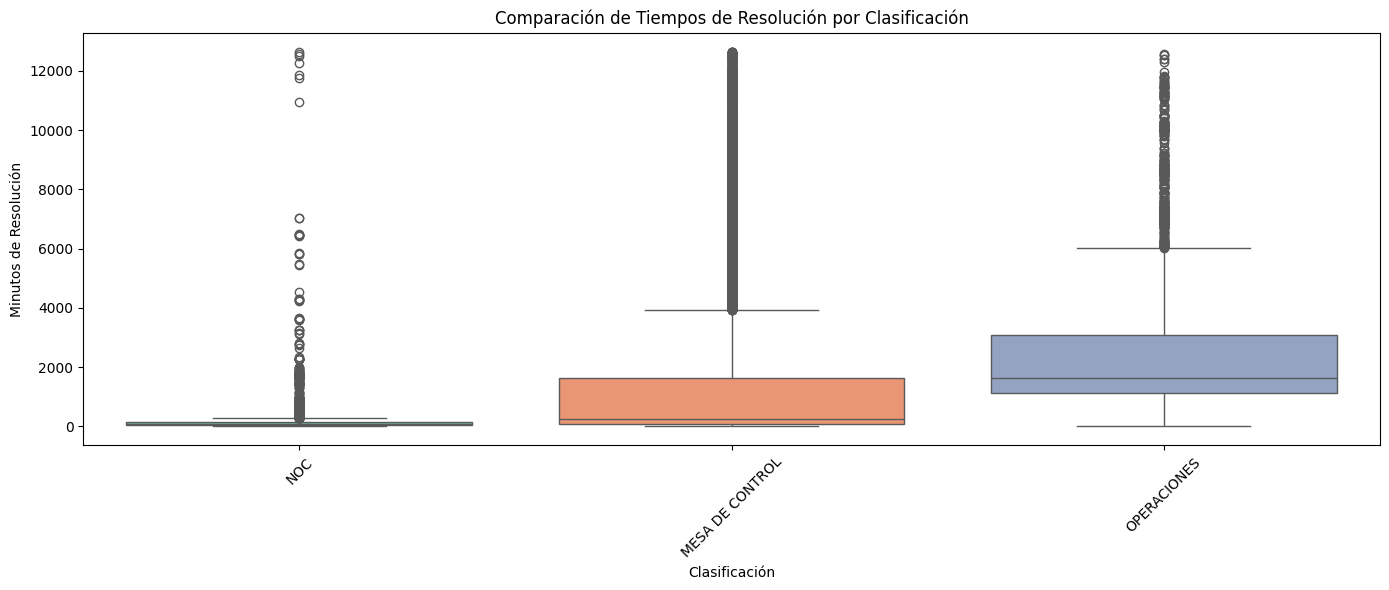

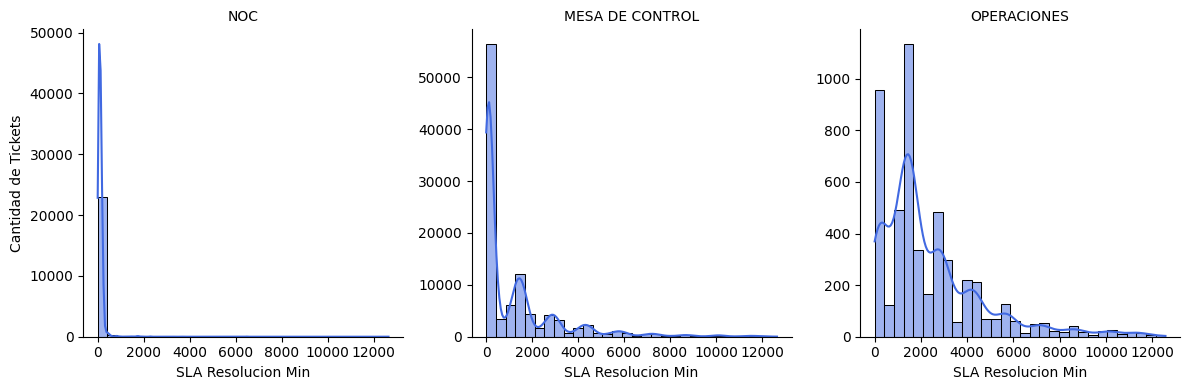

In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar y limpiar los datos (aplicando las correcciones previas)
usuario_path = os.environ['USERPROFILE']
ruta_parquet = os.path.join(usuario_path, "Documents", "A-DataStack", "01-Proyectos", "01-Data_PipelinesFibex", "02_Data_Lake", "silver_data", "Tickets_Silver_Master.parquet")
df = pd.read_parquet(ruta_parquet)

# Limpieza: Cerrados, sin nulos y tiempos > 0
df_e = df.dropna(subset=['Fecha Cierre', 'Solucion Aplicada']).copy()
df_limpio = df_e[df_e['SLA Resolucion Min'] > 0].copy()

# Filtro de outliers (Percentil 99 general) para no distorsionar las gráficas
limite_outlier = df_limpio['SLA Resolucion Min'].quantile(0.99)
df_final = df_limpio[df_limpio['SLA Resolucion Min'] <= limite_outlier].copy()

# ==========================================
# ANÁLISIS POR CLASIFICACIÓN
# ==========================================

# 1. Tabla de Estadísticas Descriptivas por Clasificación
resumen_clasificacion = df_final.groupby('Clasificacion')['SLA Resolucion Min'].agg(
    Tickets='count',
    Media='mean',
    Mediana='median',
    Minimo='min',
    Maximo='max'
).sort_values(by='Tickets', ascending=False).reset_index()

print("--- Resumen de SLA por Clasificación ---")
display(resumen_clasificacion)

# 2. Visualización 1: Boxplot Comparativo
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_final, x='Clasificacion', y='SLA Resolucion Min', palette='Set2')
plt.title('Comparación de Tiempos de Resolución por Clasificación')
plt.xlabel('Clasificación')
plt.ylabel('Minutos de Resolución')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Visualización 2: Histogramas Múltiples (FacetGrid)
# Esto creará un mini-histograma para cada categoría
g = sns.FacetGrid(df_final, col="Clasificacion", col_wrap=3, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="SLA Resolucion Min", kde=True, bins=30, color='royalblue')
g.set_titles(col_template="{col_name}")
g.set_axis_labels("SLA Resolucion Min", "Cantidad de Tickets")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import os

# 1. Cargar y limpiar datos (igual que antes)
usuario_path = os.environ['USERPROFILE']
ruta_parquet = os.path.join(usuario_path, "Documents", "A-DataStack", "01-Proyectos", "01-Data_PipelinesFibex", "02_Data_Lake", "silver_data", "Tickets_Silver_Master.parquet")
df = pd.read_parquet(ruta_parquet)

df_e = df.dropna(subset=['Fecha Cierre', 'Solucion Aplicada']).copy()
df_limpio = df_e[df_e['SLA Resolucion Min'] > 0].copy()

limite_outlier = df_limpio['SLA Resolucion Min'].quantile(0.99)
df_final = df_limpio[df_limpio['SLA Resolucion Min'] <= limite_outlier].copy()

# 2. Definir los SLAs reales extraídos de Power BI (en minutos)
metas_sla = {
    'NOC': 30,              # Meta de 30 min
    'MESA DE CONTROL': 240, # Meta de 4 horas
    'OPERACIONES': 1440     # *Valor temporal de 24h, actualizar si es distinto*
}

# 3. Función para calcular SPC y Cpk por grupo usando Clements
def calcular_metricas_spc(grupo):
    clasificacion = grupo.name
    
    # Obtener el USL del diccionario, si no existe usa 240 por defecto
    usl = metas_sla.get(clasificacion, 240) 
    
    p50 = grupo['SLA Resolucion Min'].median()
    p99_865 = np.percentile(grupo['SLA Resolucion Min'], 99.865)
    p0_135 = np.percentile(grupo['SLA Resolucion Min'], 0.135)
    
    if p99_865 == p50:
        cpk = 0 
    else:
        # Fórmula de Clements adaptada para un solo límite (USL)
        cpk = (usl - p50) / (p99_865 - p50)
    
    return pd.Series({
        'Meta_SLA_Min': usl,
        'Mediana_Proceso_CL': p50,
        'LCL_Shewhart': p0_135,
        'UCL_Shewhart': p99_865,
        'Cpk_Valor': round(cpk, 4),
        'Tickets_Evaluados': len(grupo)
    })

# 4. Aplicar los cálculos a cada clasificación
df_spc_agrupado = df_final.groupby('Clasificacion').apply(calcular_metricas_spc).reset_index()

print("--- Métricas SPC Finales ---")
display(df_spc_agrupado)

# 5. Integrar las métricas de vuelta a la tabla principal para Power BI
df_gold = pd.merge(df_final, df_spc_agrupado, on='Clasificacion', how='left')

# Opcional: Guardar el parquet para que lo lea Power BI
# df_gold.to_parquet(os.path.join(usuario_path, "Documents", "A-DataStack", "01-Proyectos", "01-Data_PipelinesFibex", "02_Data_Lake", "gold_data", "Sla_Gold_SPC.parquet"))

--- Métricas SPC Finales ---


C:\Users\josperez\AppData\Local\Temp\ipykernel_28128\234185365.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_spc_agrupado = df_final.groupby('Clasificacion').apply(calcular_metricas_spc).reset_index()


,Clasificacion,Meta_SLA_Min,Mediana_Proceso_CL,LCL_Shewhart,UCL_Shewhart,Cpk_Valor,Tickets_Evaluados
0,MESA DE CONTROL,240.0,256.0,1.0,11743.34775,-0.0014,106468.0
1,NOC,30.0,101.0,1.0,3261.12615,-0.0225,24352.0
2,OPERACIONES,1440.0,1619.0,2.0,11828.00000,-0.0175,5309.0


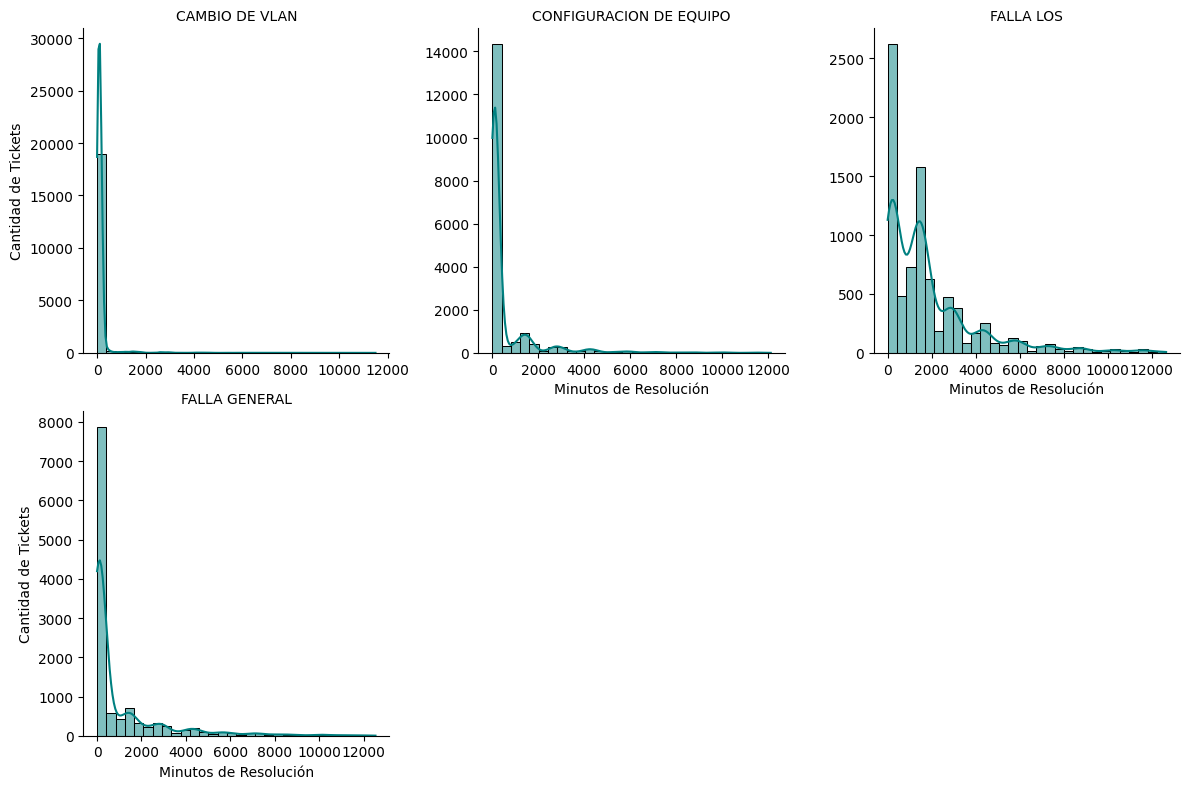

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir tu Top 5 basado en el análisis de Pareto
top_5_soluciones = [
    'CONECTOR DAÑADO',
    'CAMBIO DE VLAN',
    'CONFIGURACION DE EQUIPO',
    'FALLA GENERAL',
    'FALLA LOS'
]

# 2. Filtrar el DataFrame limpio (df_final) para quedarnos solo con el Top 5
df_pareto = df_final[df_final['Solucion Aplicada'].isin(top_5_soluciones)].copy()

# 3. Graficar los histogramas separados para ver la "limpieza" de las curvas
g = sns.FacetGrid(df_pareto, col="Solucion Aplicada", col_wrap=3, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="SLA Resolucion Min", kde=True, bins=30, color='teal')

# Dar formato a los gráficos
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Minutos de Resolución", "Cantidad de Tickets")
plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
import numpy as np

# Supongamos que df_pareto es tu tabla ya filtrada con el Top 5 de soluciones
# 1. Definir el tamaño del "depósito" o bin (ej. cada 60 minutos = 1 hora)
ancho_bin = 60
max_minutos = int(df_pareto['SLA Resolucion Min'].max())
bins = range(0, max_minutos + ancho_bin, ancho_bin)

# 2. Crear las etiquetas (ej. "0-59", "60-119", etc.)
etiquetas = [f"{i} a {i+ancho_bin-1}" for i in bins[:-1]]

# 3. Asignar cada ticket a su rango correspondiente
df_pareto['Rango_Tiempo_Min'] = pd.cut(df_pareto['SLA Resolucion Min'], bins=bins, labels=etiquetas, right=False)

# 4. AGRUPAR: Esta es la magia que comprime los datos para Power BI
df_gold_distribucion = df_pareto.groupby(['Solucion Aplicada', 'Rango_Tiempo_Min']).size().reset_index(name='Cantidad_Tickets')

# Limpiar rangos donde no hubo ningún ticket para ahorrar aún más peso
df_gold_distribucion = df_gold_distribucion[df_gold_distribucion['Cantidad_Tickets'] > 0]
display(df_gold_distribucion)
# Exportar a Parquet
# df_gold_distribucion.to_parquet("Gold_Distribucion_SLA.parquet")

,Solucion Aplicada,Rango_Tiempo_Min,Cantidad_Tickets
0,CAMBIO DE VLAN,0 a 59,5670
1,CAMBIO DE VLAN,60 a 119,6303
2,CAMBIO DE VLAN,120 a 179,4156
3,CAMBIO DE VLAN,180 a 239,2290
4,CAMBIO DE VLAN,240 a 299,448
...,...,...,...
839,FALLA LOS,12360 a 12419,2
840,FALLA LOS,12420 a 12479,1
841,FALLA LOS,12480 a 12539,1
842,FALLA LOS,12540 a 12599,5


In [37]:
import pandas as pd
df = pd.read_parquet(r'C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\gold_data\Ventas_Listado_Gold.parquet')
display(df)

,N° Abonado,Fecha Contrato,Estatus,Suscripción,Grupo Afinidad,Nombre Franquicia,Ciudad,Vendedor,nombre_detectado,Oficina,tipo_coincidencia,Tipo de afluencia,Mes,Canal
0,BQ37960,2025-12-02,SIN FACTIBILIDAD,23.2,HOGAR,FIBEX BARQUISIMETO,BARQUISIMETO,agente autorizado sistelvenca wilmer alejandro...,None,None,No detectado,VENTAS,Diciembre,ALIADOS
1,LCH80353,2025-12-02,ACTIVO,23.2,HOGAR,FIBEX ANZOATEGUI,CUMANA,celeste rojas gutierrez atc agente sermanca cu...,None,None,No detectado,VENTAS,Diciembre,ALIADOS
2,MI13008,2025-12-02,POR INSTALAR,23.2,HOGAR,FIBEX MIRANDA,BRION (HIGUEROTE),ivan alberto rodriguez rujano agente autorizad...,None,None,No detectado,VENTAS,Diciembre,ALIADOS
3,LCH80354,2025-12-02,ACTIVO,23.2,HOGAR,FIBEX ANZOATEGUI,CUMANA,celeste rojas gutierrez atc agente sermanca cu...,None,None,No detectado,VENTAS,Diciembre,ALIADOS
4,C49665,2025-12-02,POR INSTALAR,40.0,HOGAR,FIBEX CARACAS,CARACAS,elyabiht alejandro sanz agente autorizado fibe...,None,None,No detectado,VENTAS,Diciembre,ALIADOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121180,A70936,2025-10-31,ACTIVO,25.0,HOGAR,FIBEX ARAGUA,TURMERO,victor alfonso diaz mercado agente autorizado ...,None,None,No detectado,VENTAS,Octubre,ALIADOS
121181,A70996,2025-10-31,POR INSTALAR,25.0,HOGAR,FIBEX ARAGUA,SANTA RITA,yoliana carolina paez ofic aragua,YOLIANA CAROLINA PAEZ OFIC ARAGUA,ARAGUA,Oficina Detectada,VENTAS,Octubre,OFICINA COMERCIAL
121182,LV4629,2025-10-31,ACTIVO,30.0,HOGAR,FIBEX LAS VEGAS,LAS VEGAS,agente autorizado intercom gts beatriz delgado,None,None,No detectado,VENTAS,Octubre,ALIADOS
121183,LCH78256,2025-10-31,ACTIVO,30.0,HOGAR,FIBEX ANZOATEGUI,PUERTO LA CRUZ,luisa nazareth sosa ventas calle oriente,None,None,No detectado,VENTAS,Octubre,VENDEDORES PROPIOS


In [ ]:
import pandas as pd
df = pd.read_parquet(r'C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\gold_data\Recaudacion_Gold.parquet')
df = df.groupby(['Fecha Contrato', 'Vendedor'], as_index=False).size()
print(df.columns)

display(df)

Index(['ID Contrato', 'ID Pago', 'N° Abonado', 'Fecha', 'Total Pago',
       'Forma de Pago', 'Banco', 'Oficina', 'Fecha Contrato', 'Estatus',
       'Suscripción', 'Grupo Afinidad', 'Nombre Franquicia', 'Ciudad',
       'Vendedor', 'Tipo de afluencia', 'Mes', 'Clasificacion',
       'Hora de Pago'],
      dtype='object')


,ID Contrato,ID Pago,N° Abonado,Fecha,Total Pago,Forma de Pago,Banco,Oficina,Fecha Contrato,Estatus,Suscripción,Grupo Afinidad,Nombre Franquicia,Ciudad,Vendedor,Tipo de afluencia,Mes,Clasificacion,Hora de Pago
0,'CONT8E932386B3200796',6957D6473D0675791646,V71522,2026-01-02,35.00,TARJETA DE DEBITO,PROVINCIAL,OFIC. TORRE FIBEX VIÑEDO,2024-07-10,ACTIVO,35.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,JHORIANNY ESPINOZA OFIC TORRE FIBEX VIñEDO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,10:00
1,'CONT543CB698DDA71852',695820C9642025193692,V4347,2026-01-02,20.00,TARJETA DE DEBITO,PROVINCIAL,OFIC. TORRE FIBEX VIÑEDO,2022-04-11,ACTIVO,20.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,JHORIANNY ESPINOZA OFIC TORRE FIBEX VIñEDO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,15:00
2,'CONT96D22C1D2D962215',6958210405DFE8263563,H5188,2026-01-02,40.00,TARJETA DE DEBITO,PROVINCIAL,OFIC. TORRE FIBEX VIÑEDO,2021-05-08,ACTIVO,40.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,JHORIANNY ESPINOZA OFIC TORRE FIBEX VIñEDO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,15:00
3,'CONT650281039D721511',6957C92C4857D9211530,LA2046,2026-01-02,6.64,EFECTIVO,None,OFC LAS ADJUNTAS,2023-11-27,ACTIVO,30.0,FIBEX EXPRESS,FIBEX LAS ADJUNTAS,CARACAS,SHERIDA GUANCHEZ OFIC LAS ADJUNTAS,RECAUDACIÓN,Enero,ALIADOS Y DESARROLLO,09:00
4,'CONT4E38E96AF2C59678',695812A7935F41748900,H9863,2026-01-02,20.00,TARJETA DE DEBITO,PROVINCIAL,OFI TINAQUILLO,2021-09-24,ACTIVO,20.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,LUISA ALEXANDRA HEREDIA TERAN OFIC TINAQUILLO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,14:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1414243,'CONTE8C3DF5192024160',698A437AD7FD68300732,V56512,2026-02-09,40.00,TARJETA DE DEBITO,PROVINCIAL,OFIC SAMBIL-VALENCIA,2024-03-06,ACTIVO,42.0,HOGAR,FIBEX VALENCIA,VALENCIA,RONELA ESTEFANIA CAMERO RAMIREZ OFIC SAMBIL VA...,RECAUDACIÓN,Febrero,OFICINAS PROPIAS,16:00
1414244,'CONT7B953B45C8594360',698A2C7E365303866658,A12782,2026-02-09,41.33,TARJETA DE DEBITO,BANCO MERCANTIL TD MARACAY,OFI-ARAGUA,2022-11-21,ACTIVO,40.0,PYMES,FIBEX ARAGUA,MARACAY,ANALIBE BEJAS MORA OFIC ARAGUA,RECAUDACIÓN,Febrero,ALIADOS Y DESARROLLO,14:00
1414245,'CONTF7B93CDDEDF51979',698A405EE66FC3306238,A55104,2026-02-09,3.75,RETENCION,RET. IVA,OFI-ARAGUA,2025-04-10,ACTIVO,29.0,PYMES,FIBEX ARAGUA,MARACAY,KARLA LINARES,RECAUDACIÓN,Febrero,ALIADOS Y DESARROLLO,16:00
1414246,'CONTF7B93CDDEDF51979',698A4097F122A1878682,A55104,2026-02-09,3.75,RETENCION,RET. IVA,OFI-ARAGUA,2025-04-10,ACTIVO,29.0,PYMES,FIBEX ARAGUA,MARACAY,KARLA LINARES,RECAUDACIÓN,Febrero,ALIADOS Y DESARROLLO,16:00


In [61]:
import polars as pl
df = pl.read_parquet(r'C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\gold_data\Recaudacion_Gold.parquet')
display(df)

ID Contrato,ID Pago,N° Abonado,Fecha,Total Pago,Forma de Pago,Banco,Oficina,Fecha Contrato,Estatus,Suscripción,Grupo Afinidad,Nombre Franquicia,Ciudad,Vendedor,Tipo de afluencia,Mes,Clasificacion,Hora de Pago
str,str,str,datetime[ns],f64,str,str,str,datetime[ns],str,f64,str,str,str,str,str,str,str,str
"""'CONT8E932386B3200796'""","""6957D6473D0675791646""","""V71522""",2026-01-02 00:00:00,35.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFIC. TORRE FIBEX VIÑEDO""",2024-07-10 00:00:00,"""ACTIVO""",35.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""JHORIANNY ESPINOZA OFIC TORRE …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""10:00"""
"""'CONT543CB698DDA71852'""","""695820C9642025193692""","""V4347""",2026-01-02 00:00:00,20.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFIC. TORRE FIBEX VIÑEDO""",2022-04-11 00:00:00,"""ACTIVO""",20.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""JHORIANNY ESPINOZA OFIC TORRE …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""15:00"""
"""'CONT96D22C1D2D962215'""","""6958210405DFE8263563""","""H5188""",2026-01-02 00:00:00,40.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFIC. TORRE FIBEX VIÑEDO""",2021-05-08 00:00:00,"""ACTIVO""",40.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""JHORIANNY ESPINOZA OFIC TORRE …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""15:00"""
"""'CONT650281039D721511'""","""6957C92C4857D9211530""","""LA2046""",2026-01-02 00:00:00,6.64,"""EFECTIVO""",null,"""OFC LAS ADJUNTAS""",2023-11-27 00:00:00,"""ACTIVO""",30.0,"""FIBEX EXPRESS""","""FIBEX LAS ADJUNTAS""","""CARACAS""","""SHERIDA GUANCHEZ OFIC LAS ADJU…","""RECAUDACIÓN""","""Enero""","""ALIADOS Y DESARROLLO""","""09:00"""
"""'CONT4E38E96AF2C59678'""","""695812A7935F41748900""","""H9863""",2026-01-02 00:00:00,20.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFI TINAQUILLO""",2021-09-24 00:00:00,"""ACTIVO""",20.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""LUISA ALEXANDRA HEREDIA TERAN …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""14:00"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""'CONTE8C3DF5192024160'""","""698A437AD7FD68300732""","""V56512""",2026-02-09 00:00:00,40.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFIC SAMBIL-VALENCIA""",2024-03-06 00:00:00,"""ACTIVO""",42.0,"""HOGAR""","""FIBEX VALENCIA""","""VALENCIA""","""RONELA ESTEFANIA CAMERO RAMIRE…","""RECAUDACIÓN""","""Febrero""","""OFICINAS PROPIAS""","""16:00"""
"""'CONT7B953B45C8594360'""","""698A2C7E365303866658""","""A12782""",2026-02-09 00:00:00,41.33,"""TARJETA DE DEBITO""","""BANCO MERCANTIL TD MARACAY""","""OFI-ARAGUA""",2022-11-21 00:00:00,"""ACTIVO""",40.0,"""PYMES""","""FIBEX ARAGUA""","""MARACAY""","""ANALIBE BEJAS MORA OFIC ARAGUA""","""RECAUDACIÓN""","""Febrero""","""ALIADOS Y DESARROLLO""","""14:00"""
"""'CONTF7B93CDDEDF51979'""","""698A405EE66FC3306238""","""A55104""",2026-02-09 00:00:00,3.75,"""RETENCION""","""RET. IVA""","""OFI-ARAGUA""",2025-04-10 00:00:00,"""ACTIVO""",29.0,"""PYMES""","""FIBEX ARAGUA""","""MARACAY""","""KARLA LINARES""","""RECAUDACIÓN""","""Febrero""","""ALIADOS Y DESARROLLO""","""16:00"""


In [ ]:
import pandas as pd
import polars as pl
from pathlib import Path
import duckdb

rutahome = Path.home()
ruta_base = rutahome / 'Documents' / 'A-DataStack' / '01-Proyectos' / '01-Data_PipelinesFibex' / '02_Data_Lake' / 'gold_data'

lf = duckdb.query


ID Contrato,ID Pago,N° Abonado,Fecha,Total Pago,Forma de Pago,Banco,Oficina,Fecha Contrato,Estatus,Suscripción,Grupo Afinidad,Nombre Franquicia,Ciudad,Vendedor,Tipo de afluencia,Mes,Clasificacion,Hora de Pago
str,str,str,datetime[ns],f64,str,str,str,datetime[ns],str,f64,str,str,str,str,str,str,str,str
"""'CONT8E932386B3200796'""","""6957D6473D0675791646""","""V71522""",2026-01-02 00:00:00,35.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFIC. TORRE FIBEX VIÑEDO""",2024-07-10 00:00:00,"""ACTIVO""",35.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""JHORIANNY ESPINOZA OFIC TORRE …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""10:00"""
"""'CONT543CB698DDA71852'""","""695820C9642025193692""","""V4347""",2026-01-02 00:00:00,20.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFIC. TORRE FIBEX VIÑEDO""",2022-04-11 00:00:00,"""ACTIVO""",20.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""JHORIANNY ESPINOZA OFIC TORRE …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""15:00"""
"""'CONT96D22C1D2D962215'""","""6958210405DFE8263563""","""H5188""",2026-01-02 00:00:00,40.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFIC. TORRE FIBEX VIÑEDO""",2021-05-08 00:00:00,"""ACTIVO""",40.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""JHORIANNY ESPINOZA OFIC TORRE …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""15:00"""
"""'CONT650281039D721511'""","""6957C92C4857D9211530""","""LA2046""",2026-01-02 00:00:00,6.64,"""EFECTIVO""",null,"""OFC LAS ADJUNTAS""",2023-11-27 00:00:00,"""ACTIVO""",30.0,"""FIBEX EXPRESS""","""FIBEX LAS ADJUNTAS""","""CARACAS""","""SHERIDA GUANCHEZ OFIC LAS ADJU…","""RECAUDACIÓN""","""Enero""","""ALIADOS Y DESARROLLO""","""09:00"""
"""'CONT4E38E96AF2C59678'""","""695812A7935F41748900""","""H9863""",2026-01-02 00:00:00,20.0,"""TARJETA DE DEBITO""","""PROVINCIAL""","""OFI TINAQUILLO""",2021-09-24 00:00:00,"""ACTIVO""",20.0,"""FIBEX EXPRESS""","""FIBEX VALENCIA""","""VALENCIA""","""LUISA ALEXANDRA HEREDIA TERAN …","""RECAUDACIÓN""","""Enero""","""OFICINAS PROPIAS""","""14:00"""


,ID Contrato,ID Pago,N° Abonado,Fecha,Total Pago,Forma de Pago,Banco,Oficina,Fecha Contrato,Estatus,Suscripción,Grupo Afinidad,Nombre Franquicia,Ciudad,Vendedor,Tipo de afluencia,Mes,Clasificacion,Hora de Pago
0,'CONT8E932386B3200796',6957D6473D0675791646,V71522,2026-01-02,35.00,TARJETA DE DEBITO,PROVINCIAL,OFIC. TORRE FIBEX VIÑEDO,2024-07-10,ACTIVO,35.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,JHORIANNY ESPINOZA OFIC TORRE FIBEX VIñEDO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,10:00
1,'CONT543CB698DDA71852',695820C9642025193692,V4347,2026-01-02,20.00,TARJETA DE DEBITO,PROVINCIAL,OFIC. TORRE FIBEX VIÑEDO,2022-04-11,ACTIVO,20.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,JHORIANNY ESPINOZA OFIC TORRE FIBEX VIñEDO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,15:00
2,'CONT96D22C1D2D962215',6958210405DFE8263563,H5188,2026-01-02,40.00,TARJETA DE DEBITO,PROVINCIAL,OFIC. TORRE FIBEX VIÑEDO,2021-05-08,ACTIVO,40.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,JHORIANNY ESPINOZA OFIC TORRE FIBEX VIñEDO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,15:00
3,'CONT650281039D721511',6957C92C4857D9211530,LA2046,2026-01-02,6.64,EFECTIVO,None,OFC LAS ADJUNTAS,2023-11-27,ACTIVO,30.0,FIBEX EXPRESS,FIBEX LAS ADJUNTAS,CARACAS,SHERIDA GUANCHEZ OFIC LAS ADJUNTAS,RECAUDACIÓN,Enero,ALIADOS Y DESARROLLO,09:00
4,'CONT4E38E96AF2C59678',695812A7935F41748900,H9863,2026-01-02,20.00,TARJETA DE DEBITO,PROVINCIAL,OFI TINAQUILLO,2021-09-24,ACTIVO,20.0,FIBEX EXPRESS,FIBEX VALENCIA,VALENCIA,LUISA ALEXANDRA HEREDIA TERAN OFIC TINAQUILLO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,14:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,'CONT2749D80F76F85950',695C20F9A4D490423661,BQ7187,2026-01-05,24.99,TARJETA DE DEBITO,PROVINCIAL,OFIC-METROPOLIS-BQTO,2023-03-31,ACTIVO,25.0,HOGAR,FIBEX BARQUISIMETO,BARQUISIMETO,NANCY KARELIS DUARTE RIVAS OFIC METROPOLIS BQTO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,16:00
4996,'CONT7129F649F0019608',CONT7129F649F0019608,BQ32847,2026-01-05,25.00,EFECTIVO DOLLAR,None,OFIC-METROPOLIS-BQTO,2025-07-11,ACTIVO,25.0,HOGAR,FIBEX BARQUISIMETO,BARQUISIMETO,NANCY KARELIS DUARTE RIVAS OFIC METROPOLIS BQTO,RECAUDACIÓN,Enero,OFICINAS PROPIAS,16:00
4997,'CONT7C10009B3EE73418',695BA78DB6D095969763,FH2773,2026-01-05,26.55,EFECTIVO,None,OFC COBRO CENTRO,2025-01-06,ACTIVO,35.0,HOGAR,FIBER HOGAR - MATURIN,MATURIN,ELOINA ARTEAGA,RECAUDACIÓN,Enero,ALIADOS Y DESARROLLO,08:00
4998,'CONT12D62A0A4A971789',695BA90B67BF00831273,FM4641,2026-01-05,30.00,TARJETA DE DEBITO,PROVINCIAL,OFC COBRO CENTRO,2025-04-30,ACTIVO,30.0,HOGAR,FIBEX MATURIN,MATURIN,ELOINA ARTEAGA,RECAUDACIÓN,Enero,ALIADOS Y DESARROLLO,08:00


In [ ]:
import pandas as pd 
df = pd.read_parquet(r'C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\gold_data\Ventas_Estatus_Gold.parquet')
df_ventas = pd.read_parquet(r'C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\gold_data\Ventas_Listado_Gold.parquet')
mask_march = (df['Fecha'] >= ('2026-03-01'))
mask_march_ventas = (df_ventas['Fecha Contrato'] >= ('2026-03-01')) & (df_ventas.Canal == 'OFICINA COMERCIAL')

df_ventas_march = df_ventas[mask_march_ventas]
df_e = df[mask_march]
df_group = df_e.groupby(['Estatus']).agg(
    Cantidad = ('N° Abonado', 'count'))
display(df_group)

df_merge = df_e.merge(df_ventas_march,
                      left_on = ['N° Abonado'], right_on = ['N° Abonado'], how = 'outer', indicator=True)
display(df_merge)

,Cantidad
Estatus,
ACTIVO,368
ANULADO,7
OBSTRUCCION,3
POR IMPLEMENTACION,23
POR INSTALAR,63
POR VGT,2
REEMBOLSO ADM,4
REEMBOLSO PAGADOS,5
REEMBOLSO SIN DATOS BANCO,1


,N° Abonado,Documento,Estatus_x,Fecha,Vendedor_x,Costo,Grupo Afinidad_x,Nombre Franquicia_x,Ciudad_x,Hora,...,Nombre Franquicia_y,Ciudad_y,Vendedor_y,nombre_detectado,Oficina_y,tipo_coincidencia,Tipo de afluencia_y,Mes,Canal,_merge
0,A77786,22343674.0,ACTIVO,2026-03-01,ANGELICA ANGULO OFIC ARAGUA,39.0,HOGAR,FIBEX ARAGUA,MARACAY,17:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,A77793,18692257.0,ACTIVO,2026-03-02,FRANKELLY GABRIELA GARCIA OFIC ARAGUA,0.0,HOGAR,FIBEX ARAGUA,EL LIMóN,10:00,...,FIBEX ARAGUA,EL LIMÓN,frankelly gabriela garcia ofic aragua,FRANKELLY GABRIELA GARCIA OFIC ARAGUA,ARAGUA,Oficina Detectada,VENTAS,Marzo,OFICINA COMERCIAL,both
2,A77876,23791377.0,ACTIVO,2026-03-03,ANGELICA ANGULO OFIC ARAGUA,39.0,HOGAR,FIBEX ARAGUA,MARACAY,11:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
3,A77903,20107254.0,ANULADO,2026-03-03,ANGELICA ANGULO OFIC ARAGUA,29.0,HOGAR,FIBEX ARAGUA,MARACAY,17:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
4,A77915,17273691.0,ACTIVO,2026-03-04,YOLIANA CAROLINA PAEZ OFIC ARAGUA,39.0,HOGAR,FIBEX ARAGUA,SANTA RITA,09:00,...,FIBEX ARAGUA,SANTA RITA,yoliana carolina paez ofic aragua,YOLIANA CAROLINA PAEZ OFIC ARAGUA,ARAGUA,Oficina Detectada,VENTAS,Marzo,OFICINA COMERCIAL,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,V138291,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,FIBEX VALENCIA,VALENCIA,mayra pacheco ofic torre fibex vinedo,MAIRA PACHECO,SAMBIL,Fuzzy,VENTAS,Marzo,OFICINA COMERCIAL,right_only
488,V138303,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,FIBEX VALENCIA,VALENCIA,mayra pacheco ofic torre fibex vinedo,MAIRA PACHECO,SAMBIL,Fuzzy,VENTAS,Marzo,OFICINA COMERCIAL,right_only
489,V138304,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,FIBEX VALENCIA,VALENCIA,katiuska daniela c mendez ofi sambil valencia,KATIUSKA DANIELA C MENDEZ OFI SAMBIL VALENCIA,SAMBIL VALENCIA,Oficina Detectada,VENTAS,Marzo,OFICINA COMERCIAL,right_only
490,YG3189,257759633.0,ACTIVO,2026-03-05,STEPHANIE MENDEZ OFIC EL PARRAL VALENCIA,39.0,HOGAR,FIBEX YAGUA,YAGUA,11:00,...,FIBEX YAGUA,YAGUA,stephanie mendez ofic el parral valencia,STEPHANIE MENDEZ,SAMBIL,Exacta,VENTAS,Marzo,OFICINA COMERCIAL,both


In [8]:
import pandas as pd
import numpy as np

# =========================================================================
# 1. CARGA DE DATOS Y PREPARACIÓN DE FECHAS
# =========================================================================
print("⏳ Cargando datos y formateando fechas...")
ruta = r'C:\Users\josperez\Documents\A-DataStack\01-Proyectos\01-Data_PipelinesFibex\02_Data_Lake\silver_data\Tickets_Silver_Master.parquet'
df = pd.read_parquet(ruta)

# Convertimos a datetime las columnas con hora exacta para cálculos precisos
df['Fecha Apertura'] = pd.to_datetime(df['Fecha Apertura'])
df['Fecha Cierre'] = pd.to_datetime(df['Fecha Cierre'])
df['Fecha Impresion'] = pd.to_datetime(df['Fecha Impresion'])

# =========================================================================
# 2. ANÁLISIS 1: RECURRENCIA POR LA MISMA CAUSA (FCR PURO)
# =========================================================================
print("🔍 Calculando Delta de Tiempo y Supervivencia de Soluciones...")
# Ordenamos cronológicamente por contrato y por falla
df = df.sort_values(['N° Contrato', 'Detalle Orden', 'Fecha Apertura'])

# Traemos la fecha de apertura del SIGUIENTE ticket (mismo cliente, misma falla)
df['Siguiente_Apertura'] = df.groupby(['N° Contrato', 'Detalle Orden'])['Fecha Apertura'].shift(-1)

# Supervivencia = Fecha en que volvió a fallar - Fecha en que se "resolvió" la vez anterior
df['Supervivencia_Dias'] = (df['Siguiente_Apertura'] - df['Fecha Cierre']).dt.total_seconds() / 86400.0

# Agrupación base (El truco de las comas para ver el historial en una celda)
df_causas = df.groupby(['Quincena Evaluada', 'N° Contrato', 'Detalle Orden']).agg(
    Repeticiones = ('N° Contrato', 'size'),
    Fechas_Atendidas = ('Fecha Apertura Date', lambda x: '; '.join(x.dropna().astype(str).unique())),
    Soluciones = ('Solucion Aplicada', lambda x: '; '.join(x.dropna().astype(str).unique())),
    Promedio_Supervivencia_Dias = ('Supervivencia_Dias', 'mean')
).reset_index()

df_causas['Promedio_Supervivencia_Dias'] = df_causas['Promedio_Supervivencia_Dias'].round(1)

# Aislamos los casos críticos de MISMA CAUSA (Los ~8,000 históricos)
df_recurrentes_detalle = df_causas[df_causas['Repeticiones'] > 1].copy()

# =========================================================================
# 3. EL PARETO ESTRATÉGICO (80/20) PARA LA MISMA CAUSA
# =========================================================================
print("📊 Generando Análisis de Pareto...")
ranking_fallas = df_recurrentes_detalle.groupby('Detalle Orden').agg(
    Casos_Afectados = ('N° Contrato', 'nunique'),
    Total_Tickets_Involucrados = ('Repeticiones', 'sum'), # Nombre claro
    Supervivencia_Promedio_Dias = ('Promedio_Supervivencia_Dias', 'mean')
).sort_values('Total_Tickets_Involucrados', ascending=False)

# Matemáticas del Pareto
total_reaperturas = ranking_fallas['Total_Tickets_Involucrados'].sum()
ranking_fallas['%_Del_Total'] = (ranking_fallas['Total_Tickets_Involucrados'] / total_reaperturas) * 100
ranking_fallas['%_Acumulado_Pareto'] = ranking_fallas['%_Del_Total'].cumsum()

# Limpieza visual de decimales
ranking_fallas['Supervivencia_Promedio_Dias'] = ranking_fallas['Supervivencia_Promedio_Dias'].round(1)
ranking_fallas['%_Del_Total'] = ranking_fallas['%_Del_Total'].round(2)
ranking_fallas['%_Acumulado_Pareto'] = ranking_fallas['%_Acumulado_Pareto'].round(2)

# Resumen Temporal (Evolución por Quincena para la misma causa)
ranking_quincena = df_recurrentes_detalle.groupby('Quincena Evaluada').agg(
    Casos_Afectados = ('N° Contrato', 'nunique'),
    Total_Tickets_Involucrados = ('Repeticiones', 'sum'),
    Supervivencia_Promedio_Dias = ('Promedio_Supervivencia_Dias', 'mean')
).sort_values('Quincena Evaluada', ascending=True)

ranking_quincena['Supervivencia_Promedio_Dias'] = ranking_quincena['Supervivencia_Promedio_Dias'].round(1)

# =========================================================================
# 4. ANÁLISIS 2: FRICCIÓN GENERAL (EL UNIVERSO DE LOS 38K)
# =========================================================================
print("🔄 Analizando el Universo de Fricción General (Todos los reclamos múltiples)...")
# Ordenamos solo por contrato y fecha para ver el viaje real del cliente
df_ordenado_cliente = df.sort_values(['N° Contrato', 'Fecha Apertura'])

# Agrupamos por Quincena y Contrato para sacar el Total Real por cliente
df_general = df_ordenado_cliente.groupby(['Quincena Evaluada', 'N° Contrato']).agg(
    Total_Tickets = ('N° Contrato', 'size'),
    # Unimos todas las causas con una flecha, sean iguales o diferentes
    Viaje_Fallas = ('Detalle Orden', lambda x: ' ➔ '.join(x.dropna().astype(str))), 
    Cantidad_Causas_Distintas = ('Detalle Orden', 'nunique')
).reset_index()

# EL UNIVERSO: Absolutamente todos los clientes con > 1 ticket (Tus 38,000)
df_friccion_total = df_general[df_general['Total_Tickets'] > 1].copy()

# Ranking general de combinaciones (te mostrará tanto "Lentitud ➔ Lentitud" como "Lentitud ➔ Corte")
ranking_friccion = df_friccion_total.groupby('Viaje_Fallas').agg(
    Casos_Afectados = ('N° Contrato', 'nunique'),
    Total_Tickets_Involucrados = ('Total_Tickets', 'sum')
).sort_values('Casos_Afectados', ascending=False)


# =========================================================================
# 5. ANÁLISIS 3: REINCIDENCIA POR GRUPO DE TRABAJO (AUDITORÍA FCR)
# =========================================================================
print("👥 Calculando Tasa de Reincidencia por Grupo de Trabajo...")
# Si un ticket tiene 'Siguiente_Apertura', significa que falló el FCR
df['FCR_Fallido'] = df['Siguiente_Apertura'].notna()

resumen_grupos = df.groupby('Grupo Trabajo').agg(
    Total_Tickets_Atendidos = ('N° Orden', 'count'),
    Tickets_Reincidentes = ('FCR_Fallido', 'sum'),
    Dias_Prom_Reincidencia = ('Supervivencia_Dias', 'mean')
).reset_index()

# Calculamos la Tasa de Reincidencia %
resumen_grupos['Tasa_Reincidencia_%'] = (resumen_grupos['Tickets_Reincidentes'] / resumen_grupos['Total_Tickets_Atendidos']) * 100

# Limpieza y filtrado
resumen_grupos['Tasa_Reincidencia_%'] = resumen_grupos['Tasa_Reincidencia_%'].round(2)
resumen_grupos['Dias_Prom_Reincidencia'] = resumen_grupos['Dias_Prom_Reincidencia'].round(2)

# Excluimos grupos con muy pocos tickets para no sesgar los porcentajes (opcional, ajustado a 20)
resumen_grupos = resumen_grupos[resumen_grupos['Total_Tickets_Atendidos'] >= 20]

# Ordenamos por los que más generan retrabajo
resumen_grupos = resumen_grupos.sort_values(by='Tickets_Reincidentes', ascending=False)


# =========================================================================
# 6. SELECCIÓN DE COLUMNAS PARA AUDITORÍA (Detalle Total Liviano)
# =========================================================================
columnas_esenciales = [
    'Quincena Evaluada', 'N° Contrato', 'N° Orden', 'Detalle Orden', 
    'Fecha Apertura', 'Fecha Impresion', 'Fecha Cierre', 
    'Solucion Aplicada', 'Duracion_Horas', 'SLA Resolucion Min', 
    'SLA Impresion Min', 'Cumplio_SLA', 'Franquicia', 'Grupo Trabajo'
]
df_reducido = df[columnas_esenciales].copy()

# =========================================================================
# 7. EXPORTACIÓN A EXCEL (Multi-hojas)
# =========================================================================
print("💾 Guardando el reporte estratégico en Excel...")
nombre_archivo = r'C:\Users\josperez\Downloads\Analisis_Recurrencia_FCR_Fibex2.xlsx'

with pd.ExcelWriter(nombre_archivo, engine='xlsxwriter') as writer:
    # 1. El Pareto del Subconjunto Crítico (Misma Causa - Los 8k)
    ranking_fallas.to_excel(writer, sheet_name='Pareto_Misma_Causa', index=True)
    
    # 2. El Ranking del Universo Total (Los 38k)
    ranking_friccion.to_excel(writer, sheet_name='Ranking_Friccion_General', index=True)
    
    # 3. Evolución Temporal (Misma Causa)
    ranking_quincena.to_excel(writer, sheet_name='Resumen_por_Quincena', index=True)
    
    # NUEVO: 4. Auditoría por Grupo de Trabajo
    resumen_grupos.to_excel(writer, sheet_name='Auditoria_Grupo_Trabajo', index=False)
    
    # 5. Detalle de los contratos críticos (Misma Causa - Los 8k)
    df_recurrentes_detalle.to_excel(writer, sheet_name='Detalle_Contratos_Misma', index=False)
    
    # 6. Detalle del Universo de contratos múltiples (Los 38k)
    df_friccion_total.to_excel(writer, sheet_name='Detalle_Contratos_Todos', index=False)
    
    # 7. Data origen optimizada
    df_reducido.to_excel(writer, sheet_name='Detalle_Total', index=False)

print(f"✅ ¡Éxito! Reporte corporativo generado en: {nombre_archivo}")

⏳ Cargando datos y formateando fechas...
🔍 Calculando Delta de Tiempo y Supervivencia de Soluciones...
📊 Generando Análisis de Pareto...
🔄 Analizando el Universo de Fricción General (Todos los reclamos múltiples)...
👥 Calculando Tasa de Reincidencia por Grupo de Trabajo...
💾 Guardando el reporte estratégico en Excel...
✅ ¡Éxito! Reporte corporativo generado en: C:\Users\josperez\Downloads\Analisis_Recurrencia_FCR_Fibex2.xlsx
